In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import sys
sys.path.append('../')

from src.neural_net import NeuralNetworkScratch
from src.optimizers import OptimizerEngine

In [2]:
df = pd.read_csv("../data/final_prepared.csv")

# Standardize features for stability
scaler = StandardScaler()
X = scaler.fit_transform(df.drop("median_house_value", axis=1))
y = df["median_house_value"].values.reshape(-1, 1)

print("X shape:", X.shape, "y shape:", y.shape)

X shape: (15967, 12) y shape: (15967, 1)


In [3]:
def train_model(X, y, optimizer_type="batch", epochs=50, lr=0.0001, batch_size=32, early_stop=False):
    nn = NeuralNetworkScratch(input_size=X.shape[1])
    opt = OptimizerEngine(optimizer_type=optimizer_type, learning_rate=lr, epochs=epochs, batch_size=batch_size)
    losses = []

    for epoch in range(epochs):
        # Forward pass
        y_pred, cache = nn.forward(X)

        # Compute loss (MSE)
        loss = np.mean((y_pred - y)**2)
        losses.append(loss)

        # Backward pass
        grads = nn.backward(cache, y)

        # Update parameters
        nn.W1 = opt.update_params(nn.W1, grads['dW1'], epoch)
        nn.b1 = opt.update_params(nn.b1, grads['db1'], epoch)
        nn.W2 = opt.update_params(nn.W2, grads['dW2'], epoch)
        nn.b2 = opt.update_params(nn.b2, grads['db2'], epoch)
        nn.W3 = opt.update_params(nn.W3, grads['dW3'], epoch)
        nn.b3 = opt.update_params(nn.b3, grads['db3'], epoch)

        # Early stopping
        if early_stop and epoch > 5 and abs(losses[-1] - losses[-2]) < 1e-5:
            print("Early stopping at epoch", epoch)
            break

    return nn, losses

In [4]:
results = {}

for opt_type in ["batch", "sgd", "mini-batch", "momentum", "rmsprop", "adam"]:
    print("Training with", opt_type)
    _, losses = train_model(X, y, optimizer_type=opt_type, epochs=50, lr=0.0001, batch_size=32, early_stop=True)
    results[opt_type] = losses

Training with batch
Training with sgd
Training with mini-batch
Training with momentum
Training with rmsprop
Training with adam


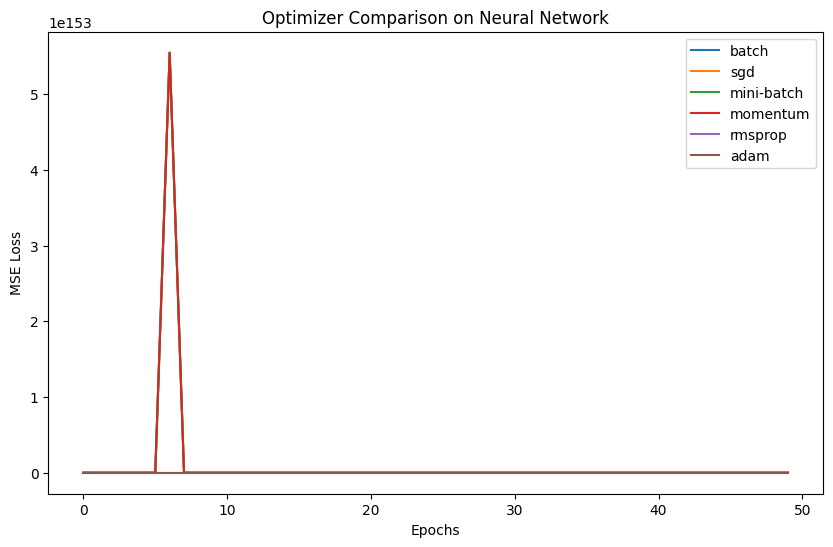

In [5]:
plt.figure(figsize=(10,6))
for name, losses in results.items():
    plt.plot(losses, label=name)
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("Optimizer Comparison on Neural Network")
plt.legend()
plt.show()

In [6]:
import pickle

# Save optimizer results for Member 4 evaluation
with open("../data/results_week5.pkl", "wb") as f:
    pickle.dump(results, f)

print("Optimizer results saved successfully!")


Optimizer results saved successfully!
